In [ ]:

from rich.jupyter import display
from torch.amp import custom_bwd
from torch.nn.functional import threshold
from transformers.models.x_clip.modeling_x_clip import x_clip_loss
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
from image_utils import ImageUtils
from dino_detector import DinoDetector
from clip_classifier import ClipClassifier
from core.models import RegionPrompt
from image_utils import ImageUtils
from core.constants import Constants
from core.plot_utils import PlotUtils
from core.constants import Constants
from core.depth import Depth
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GROUNDING_PROMPT = (
    "food, meal, cooked food, dish, plate, bowl, wooden plate, ceramic plate, cup, knife, spoon, sauce, meat, cheese"
)
FOOD_PROMPTS = ["food", "meal", "cooked food"]
CONTAINER_PROMPTS = ["plate", "bowl", "dish", "wooden plate", "ceramic plate"]

BOX_THRESHOLD = 0.30
TEXT_THRESHOLD = 0.30

# sam
SAM_CHECKPOINT = "checkpoints/sam_vit_b_01ec64.pth"
SAM_MODEL_TYPE = "vit_b"

In [ ]:
from loaders import load_openclip, load_grounding_dino, load_sam, load_depth_anything_v2

# load checkpoints
dino_model = load_grounding_dino()
sam_predictor = load_sam(SAM_CHECKPOINT, SAM_MODEL_TYPE, device=DEVICE)
depth_anything_model = load_depth_anything_v2(device=DEVICE)

# create objects
dino_detector = DinoDetector(
    device=DEVICE,
    model=dino_model
)

In [ ]:
# image
image_path = "photos/wood_dish_1.png"
# image_path = "photos/out_screen1.png"
# image_path = "photos/ok_light_2.png"
# image_path = "photos/bad_light_1.png"
# image_path = "photos/good_light_1.png"
# image_path = "photos/bad_light_2.png"
# image_path = "photos/non_subject_items_in_range.png"
# image_path = "photos/horizontal_angle.png"

# detect objects
image_source, image, boxes, phrases = dino_detector.detect_boxes(
    image_path,
    grounding_prompt=GROUNDING_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
)

regions: list[RegionPrompt] = []
for box, phrase in zip(boxes, phrases):
    region = RegionPrompt(box=box, label=phrase)
    regions.append(region)

pil_img = ImageUtils.convert_img_source_to_pil(image_source)

if Constants.DEBUG:
    ImageUtils.display_bounding_boxes(image_source, boxes)


In [ ]:
from sam_segmenter import SamSegmenter

sam_segmenter = SamSegmenter(predictor=sam_predictor, device=DEVICE)
regions_with_masks = sam_segmenter.segment(image=ImageUtils.pil_to_numpy(pil_img), regions=regions)

# ImageUtils.display_regions_with_masks(regions_with_masks)

In [ ]:
depth = depth_anything_model.infer_image(raw_image=image_source, input_size=618)
dmin = np.nanmin(depth)
dmax = np.nanmax(depth)

In [ ]:
# ======== debug= ==============
# full image (scalar)
if Constants.DEBUG:
    ImageUtils.show_depth(
        depth,
        title="Depth Anything V2",
        vmin=dmin,
        vmax=dmax,
        cmap="inferno"
    )

# masked regions (scalar)
if Constants.DEBUG:
    for region in regions_with_masks:
        PlotUtils.show_mask_depth_with_center_distance(
            mask=region.mask, image_source_depth=depth,
            title=region.label, vmin=dmin, vmax=dmax, region_label=region.label, region_box=region.box)

In [ ]:
norm_depth = Depth.normalize_depth(depth, vmin=dmin, vmax=dmax)
main_dish = Depth.compute_main_dish(depth, regions_with_masks, image_source)

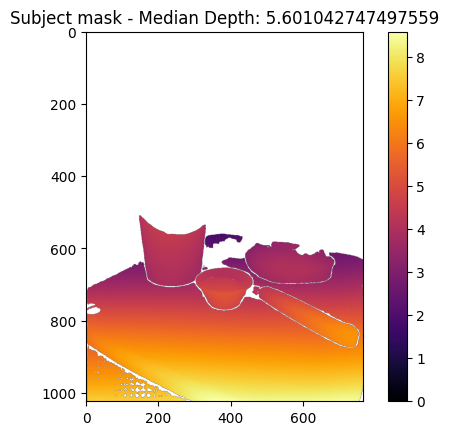

In [15]:
from core.math import Math

from core.models import Vector2, Box

if Constants.DEBUG:
    ImageUtils.show_mask_depth(
        mask=main_dish.mask,
        image_source_depth=depth,
        vmin=dmin,
        vmax=dmax,
        title=f"main dish: {main_dish.label}"
    )

support_threshold = 0.6

subject_regions = Depth.get_supported_subject_regions(
    depth=depth,
    main_dish=main_dish,
    regions_with_masks=regions_with_masks,
    support_threshold=support_threshold,
    dmin=dmin,
    dmax=dmax,
)

curr_region = Depth.merge_regions_mask(subject_regions)
Depth.compute_depth_in_range(depth, curr_region.mask)

ImageUtils.show_mask_depth(
    mask=curr_region.mask,
    image_source_depth=depth,
    vmin=dmin,
    vmax=dmax,
    title="Subject mask"
)
